In [1]:
import pandas as pd
import numpy as np



In [2]:
df=pd.read_csv("./data/pima-indians-diabetes.csv")
print(df.info())



<class 'pandas.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   6       767 non-null    int64  
 1   148     767 non-null    int64  
 2   72      767 non-null    int64  
 3   35      767 non-null    int64  
 4   0       767 non-null    int64  
 5   33.6    767 non-null    float64
 6   0.627   767 non-null    float64
 7   50      767 non-null    int64  
 8   1       767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
print(df.columns)

Index(['6', '148', '72', '35', '0', '33.6', '0.627', '50', '1'], dtype='str')


asignar nombre a las columnas

In [3]:
nameColumns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df.columns=nameColumns
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    int64  
 1   Glucose                   767 non-null    int64  
 2   BloodPressure             767 non-null    int64  
 3   SkinThickness             767 non-null    int64  
 4   Insulin                   767 non-null    int64  
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       767 non-null    int64  
 8   Outcome                   767 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


Hacer limpieza dataset

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

revisar procentajes de promedios, minimos, maximos etc

In [7]:
df.max()


Pregnancies                  17.00
Glucose                     199.00
BloodPressure               122.00
SkinThickness                99.00
Insulin                     846.00
BMI                          67.10
DiabetesPedigreeFunction      2.42
Age                          81.00
Outcome                       1.00
dtype: float64

In [8]:
df.min()

Pregnancies                  0.000
Glucose                      0.000
BloodPressure                0.000
SkinThickness                0.000
Insulin                      0.000
BMI                          0.000
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
dtype: float64

como hay valores en 0 minimo que no deberia ser 0 vamos a asignar nah para ver como tratar los datos

In [6]:
invalid_columns_0=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df[invalid_columns_0]=df[invalid_columns_0].replace(0, np.nan)

In [7]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     373
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
dfNew=df.copy()
dfNew.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
1,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
2,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
4,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0


rellenar con media

In [9]:
col=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[col]=df[col].fillna(df[col].median())

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
1,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
2,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
4,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0


box plot

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

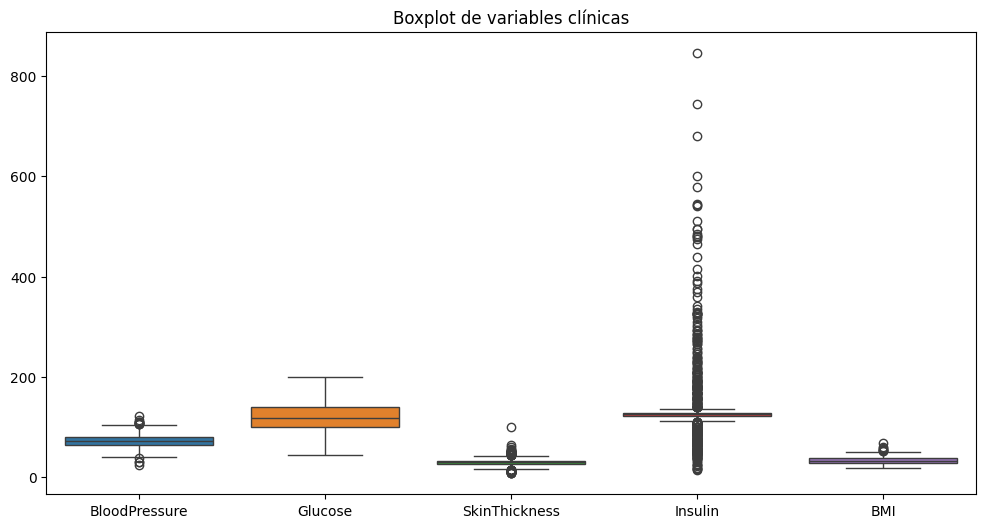

In [14]:

cols = ["BloodPressure", "Glucose", "SkinThickness", "Insulin", "BMI"]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.title("Boxplot de variables clínicas")
plt.show()


<Axes: >

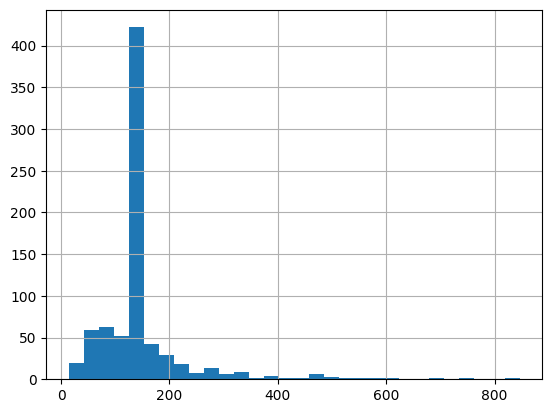

In [15]:
df["Insulin"].hist(bins=30)


In [10]:
#copio el dataframe para probar sin nah
dfSinNah=dfNew.copy()
dfSinNah=dfSinNah.dropna()
dfSinNah.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
12,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


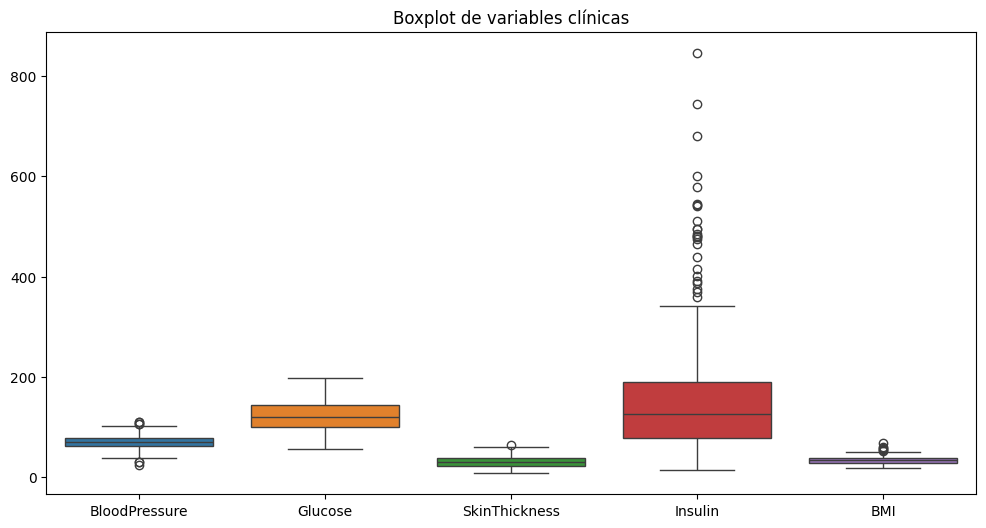

In [13]:
cols = ["BloodPressure", "Glucose", "SkinThickness", "Insulin", "BMI"]

plt.figure(figsize=(12,6))
sns.boxplot(data=dfSinNah[cols])
plt.title("Boxplot de variables clínicas")
plt.show()

<Axes: >

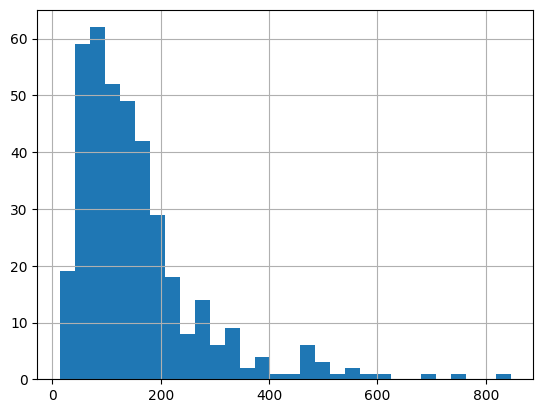

In [18]:
dfSinNah["Insulin"].hist(bins=30)

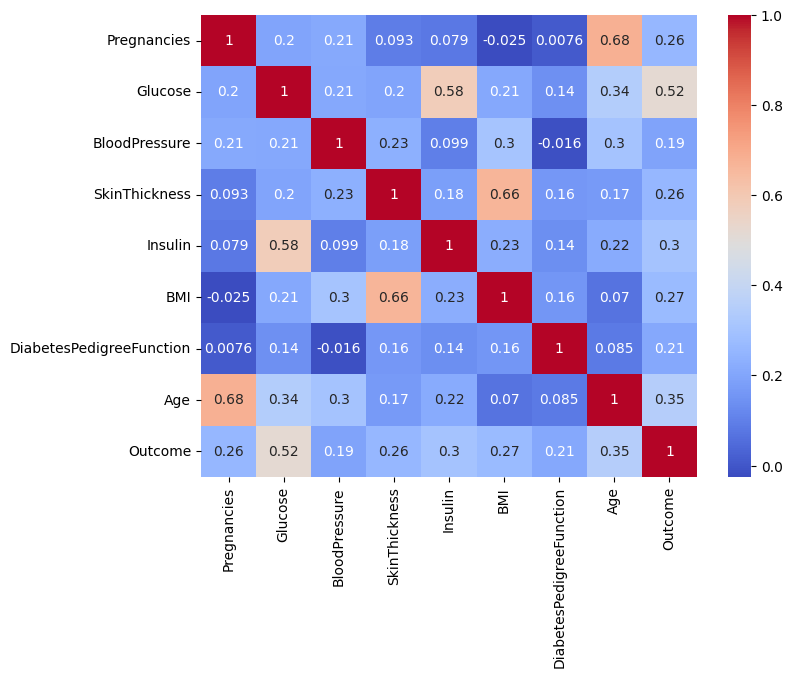

In [19]:
corr=dfSinNah.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

en relacion con outcome glucosa, bmi y age son las mas fuertes. 
hare un entrenamiento con esas 3, las 3 + insulina y otra con todas a ver cual resulta mejor

In [20]:
cols=["Glucose","Age","Insulin","BMI","Outcome"]

df4=dfSinNah[cols].copy()


dfSinNah[cols]=(dfSinNah[cols]-dfSinNah[cols].mean())/dfSinNah[cols].std()

outliers= dfSinNah[dfSinNah[cols].abs().gt(3).any(axis=1)]

outliers.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,2,2.409934,70.0,45.0,3.255961,-0.368007,0.158,2.169953,1.417831
12,1,2.150705,60.0,23.0,5.805571,-0.424924,0.398,2.758143,1.417831
124,1,-1.122057,30.0,42.0,-0.480102,3.118218,0.496,-0.476904,1.417831
176,0,0.206490,110.0,46.0,-0.219251,4.839986,0.319,-0.476904,1.417831
227,4,2.409934,70.0,39.0,4.947286,0.514222,2.329,0.013254,-0.703504


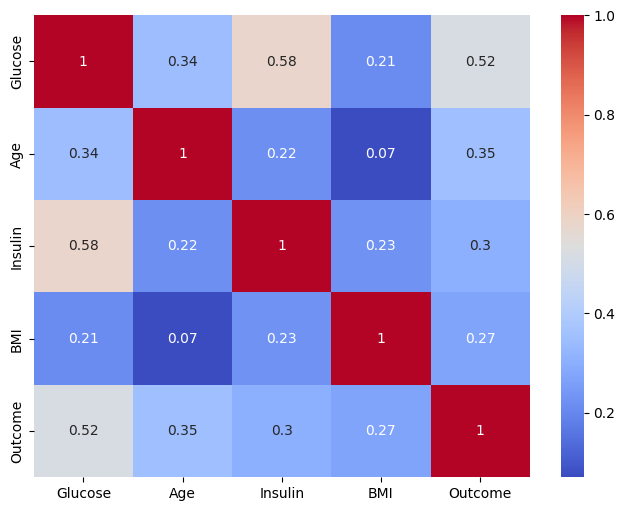

In [21]:


corr=df4.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

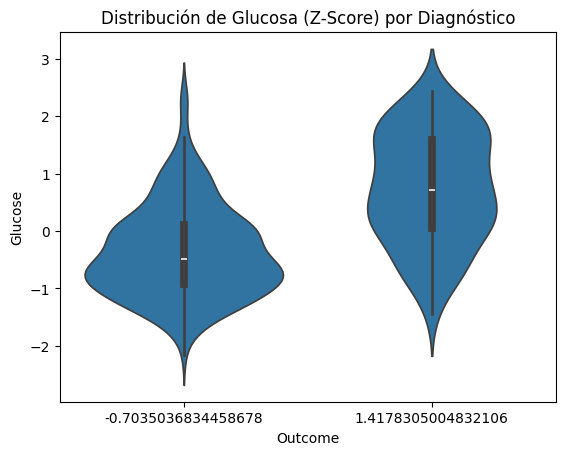

In [22]:
sns.violinplot(x='Outcome', y='Glucose', data=dfSinNah)
plt.title('Distribución de Glucosa (Z-Score) por Diagnóstico')
plt.show()

In [23]:
df4.to_csv("dfToTrain.csv", index=False)
print("dataset guardado con exito")

dataset guardado con exito


In [14]:
dfSinNah.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
3,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
12,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


In [15]:
dfSinNah.to_csv("dfToTrain2.csv", index=False)
print("dataset guardado con exito")

dataset guardado con exito


In [25]:
#guardar parametros de media y desviacion estandar
import joblib
parametros={
    "media":df4[["Glucose","Age","Insulin","BMI"]].mean(),
    "std":df4[["Glucose","Age","Insulin","BMI"]].std()
}

joblib.dump(parametros,"./modeloEntrenado/parametros.joblib")

['./modeloEntrenado/parametros.joblib']

In [26]:
df4.head()

,Glucose,Age,Insulin,BMI,Outcome
2,89.0,21,94.0,28.1,0
3,137.0,33,168.0,43.1,1
5,78.0,26,88.0,31.0,1
7,197.0,53,543.0,30.5,1
12,189.0,59,846.0,30.1,1
